# Conformer Model - Dataset m01
## 5-Class Speech Emotion Recognition

**Classes:** angry, disgust, fear, sad, neutral  
**Dataset:** `data_preprocessed/data_features_m01.csv`  
**Experiment setting:** 80/20 hold-out test split for fair comparison with DNN, CNN-LSTM, and Transformer. Validation is split only from the training portion for checkpointing and early stopping.


## Import library

In [1]:
# Import libraries
import os
import json
import random
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)


Libraries imported successfully!
TensorFlow version: 2.13.0


## Data Preparation

In [2]:
# Load dataset
DATASET_PATH = "data_preprocessed/data_features_m01.csv"

df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nLabel distribution:")
print(df["label"].value_counts())


Dataset shape: (4320, 41)

Columns:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', 'label']

Label distribution:
label
sad        960
angry      960
fear       960
disgust    960
neutral    480
Name: count, dtype: int64


In [3]:
# Filter target classes
target_classes = ["angry", "disgust", "fear", "sad", "neutral"]

df = df[df["label"].isin(target_classes)].copy()
df = df.dropna().reset_index(drop=True)

print("Filtered dataset shape:", df.shape)
print("\nClass distribution after filtering:")
display(df["label"].value_counts().to_frame("count"))

# Split features and labels
X = df.drop(columns=["label"]).values.astype("float32")
y = df["label"].values

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print("\nClasses:", list(label_encoder.classes_))
print("Number of classes:", num_classes)
print("Feature shape:", X.shape)


Filtered dataset shape: (4320, 41)

Class distribution after filtering:


,count
label,
sad,960
angry,960
fear,960
disgust,960
neutral,480



Classes: ['angry', 'disgust', 'fear', 'neutral', 'sad']
Number of classes: 5
Feature shape: (4320, 40)


In [4]:
# Train / validation / test split
# Main comparison uses 80/20 hold-out test split:
# - Test set = 20% of full augmented dataset, consistent with DNN/CNN-LSTM/Transformer.
# - Validation set is split only from the training portion for EarlyStopping and ModelCheckpoint.
X_train_full_raw, X_test_raw, y_train_full, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_full_raw,
    y_train_full,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train_full
)

# Fit scaler on training subset only, then transform validation/test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Conformer input: (samples, timesteps, channels)
# Each engineered acoustic feature is treated as one token/timestep.
X_train_cf = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_val_cf = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
X_test_cf = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# One-hot labels
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("Full dataset:", X.shape, y_encoded.shape)
print("Train:", X_train_cf.shape, y_train_cat.shape)
print("Validation:", X_val_cf.shape, y_val_cat.shape)
print("Test:", X_test_cf.shape, y_test_cat.shape)
print("Test ratio:", round(len(y_test) / len(y_encoded), 4))


Full dataset: (4320, 40) (4320,)
Train: (3110, 40, 1) (3110, 5)
Validation: (346, 40, 1) (346, 5)
Test: (864, 40, 1) (864, 5)
Test ratio: 0.2


In [5]:
# Declare output paths
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_NAME = "conformer"
MODEL_VERSION = "m01"

BEST_MODEL_PATH = os.path.join(MODEL_DIR, f"best_{MODEL_NAME}_model_{MODEL_VERSION}.h5")
SCALER_PATH = os.path.join(MODEL_DIR, f"scaler_{MODEL_NAME}_{MODEL_VERSION}.pkl")
LABEL_ENCODER_PATH = os.path.join(MODEL_DIR, f"label_encoder_{MODEL_NAME}_{MODEL_VERSION}.pkl")
HISTORY_PATH = os.path.join(MODEL_DIR, f"history_{MODEL_NAME}_{MODEL_VERSION}.pkl")
METRICS_PATH = os.path.join(MODEL_DIR, f"metrics_{MODEL_NAME}_{MODEL_VERSION}.json")
CM_PLOT_PATH = os.path.join(MODEL_DIR, f"confusion_matrix_{MODEL_NAME}_{MODEL_VERSION}.png")
HISTORY_PLOT_PATH = os.path.join(MODEL_DIR, f"training_history_{MODEL_NAME}_{MODEL_VERSION}.png")

print("Best model path:", BEST_MODEL_PATH)
print("Scaler path:", SCALER_PATH)
print("Label encoder path:", LABEL_ENCODER_PATH)


Best model path: models\best_conformer_model_m01.h5
Scaler path: models\scaler_conformer_m01.pkl
Label encoder path: models\label_encoder_conformer_m01.pkl


## Build model

In [6]:
# Conformer configuration
# Keep max epochs aligned with other deep learning models for fair academic comparison.
D_MODEL = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_BLOCKS = 3
CONV_KERNEL_SIZE = 7
DROPOUT_RATE = 0.25
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.03

# Main result setting:
# Keep False for fair comparison if DNN/CNN-LSTM/Transformer do not use class_weight.
# Set True only for an ablation experiment.
USE_CLASS_WEIGHT = False


def feed_forward_module(x, ff_dim, dropout=0.25):
    """Macaron-style feed-forward module used in Conformer."""
    residual = x

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(ff_dim, activation="swish")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(residual.shape[-1])(x)
    x = layers.Dropout(dropout)(x)

    return residual + 0.5 * x


def convolution_module(x, embed_dim, kernel_size=7, dropout=0.25):
    """Conformer convolution module: pointwise -> GLU -> depthwise -> BN -> pointwise."""
    residual = x

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Conv1D(filters=2 * embed_dim, kernel_size=1, padding="same")(x)

    # GLU-style gating
    x_a = layers.Lambda(lambda t: t[:, :, :embed_dim])(x)
    x_b = layers.Lambda(lambda t: t[:, :, embed_dim:])(x)
    x = layers.Multiply()([x_a, layers.Activation("sigmoid")(x_b)])

    x = layers.SeparableConv1D(
        filters=embed_dim,
        kernel_size=kernel_size,
        padding="same",
        activation="swish"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=embed_dim, kernel_size=1, padding="same")(x)
    x = layers.Dropout(dropout)(x)

    return residual + x


def conformer_block(x, embed_dim=128, num_heads=4, ff_dim=256, kernel_size=7, dropout=0.25):
    """Conformer block: FFN -> MHSA -> Conv -> FFN -> LayerNorm."""
    # Feed-forward module 1
    x = feed_forward_module(x, ff_dim=ff_dim, dropout=dropout)

    # Multi-head self-attention module
    residual = x
    x_norm = layers.LayerNormalization(epsilon=1e-6)(x)

    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout
    )(x_norm, x_norm)

    attn = layers.Dropout(dropout)(attn)
    x = residual + attn

    # Convolution module
    x = convolution_module(
        x,
        embed_dim=embed_dim,
        kernel_size=kernel_size,
        dropout=dropout
    )

    # Feed-forward module 2
    x = feed_forward_module(x, ff_dim=ff_dim, dropout=dropout)

    return layers.LayerNormalization(epsilon=1e-6)(x)


def build_conformer_model(
    input_shape,
    num_classes,
    embed_dim=128,
    num_heads=4,
    ff_dim=256,
    num_blocks=3,
    kernel_size=7,
    dropout=0.25
):
    inputs = Input(shape=input_shape)

    # Input projection
    x = layers.Dense(embed_dim)(inputs)

    # Learnable positional embedding
    positions = tf.range(start=0, limit=input_shape[0], delta=1)
    pos_embedding = layers.Embedding(
        input_dim=input_shape[0],
        output_dim=embed_dim
    )(positions)

    x = x + pos_embedding

    # Conformer encoder blocks
    for _ in range(num_blocks):
        x = conformer_block(
            x,
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            kernel_size=kernel_size,
            dropout=dropout
        )

    # Classification head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="swish")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(64, activation="swish")(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="Conformer_EmotionRecognition_m01"
    )

    return model


input_shape = (X_train_cf.shape[1], X_train_cf.shape[2])

model = build_conformer_model(
    input_shape=input_shape,
    num_classes=num_classes,
    embed_dim=D_MODEL,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_blocks=NUM_BLOCKS,
    kernel_size=CONV_KERNEL_SIZE,
    dropout=DROPOUT_RATE
)

# AdamW is preferred for Transformer/Conformer-style models.
try:
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
except AttributeError:
    print("AdamW is not available in this TensorFlow version. Falling back to Adam.")
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=["accuracy"]
)

model.summary()


Model: "Conformer_EmotionRecognition_m01"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 40, 1)]              0         []                            
                                                                                                  
 dense (Dense)               (None, 40, 128)              256       ['input_1[0][0]']             
                                                                                                  
 tf.__operators__.add (TFOp  (None, 40, 128)              0         ['dense[0][0]']               
 Lambda)                                                                                          
                                                                                                  
 layer_normalization (Layer  (None, 40, 128)              256      

## Train model

In [7]:
# Optional class weighting
# For the main comparison table, keep USE_CLASS_WEIGHT = False because the other models were not trained with class weights.
# If running an ablation experiment, set USE_CLASS_WEIGHT = True to enable sqrt-balanced class weights.
if USE_CLASS_WEIGHT:
    class_weights_values = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train
    )

    class_weights = {
        int(class_id): float(np.sqrt(weight))
        for class_id, weight in zip(np.unique(y_train), class_weights_values)
    }

    print("Soft class weights enabled:")
    for idx, weight in class_weights.items():
        print(f"{label_encoder.classes_[idx]}: {weight:.4f}")
else:
    class_weights = None
    print("Class weights disabled for fair comparison with DNN/CNN-LSTM/Transformer.")


Class weights disabled for fair comparison with DNN/CNN-LSTM/Transformer.


In [8]:
# Callbacks
checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=18,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    mode="min",
    verbose=1
)

callbacks = [checkpoint, early_stop, lr_scheduler]

history = model.fit(
    X_train_cf,
    y_train_cat,
    validation_data=(X_val_cf, y_val_cat),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

print("Training completed.")
print("Best model saved at:", BEST_MODEL_PATH)


Epoch 1/100
98/98 [==============================] - ETA: 0s - loss: 1.9150 - accuracy: 0.2309   
Epoch 1: val_accuracy improved from -inf to 0.22543, saving model to models\best_conformer_model_m01.h5
98/98 [==============================] - 41s 248ms/step - loss: 1.9150 - accuracy: 0.2309 - val_loss: 1.6667 - val_accuracy: 0.2254 - lr: 3.0000e-04
Epoch 2/100
98/98 [==============================] - ETA: 0s - loss: 1.7269 - accuracy: 0.2608 
Epoch 2: val_accuracy improved from 0.22543 to 0.24855, saving model to models\best_conformer_model_m01.h5
98/98 [==============================] - 23s 235ms/step - loss: 1.7269 - accuracy: 0.2608 - val_loss: 1.7548 - val_accuracy: 0.2486 - lr: 3.0000e-04
Epoch 3/100
98/98 [==============================] - ETA: 0s - loss: 1.6311 - accuracy: 0.3071 
Epoch 3: val_accuracy improved from 0.24855 to 0.28324, saving model to models\best_conformer_model_m01.h5
98/98 [==============================] - 26s 265ms/step - loss: 1.6311 - accuracy: 0.3071 - va

## Predict on test set

In [9]:
# Load the best checkpoint before final evaluation
best_model = load_model(BEST_MODEL_PATH)

y_pred_probs = best_model.predict(X_test_cf, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

test_loss, test_accuracy = best_model.evaluate(X_test_cf, y_test_cat, verbose=0)

print("Test Accuracy:", round(float(test_accuracy), 4))
print("Test Loss:", round(float(test_loss), 4))


Test Accuracy: 0.838
Test Loss: 0.5558


## Evaluation

In [10]:
# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, digits=4))

# Cohen's Kappa
kappa = cohen_kappa_score(y_true, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")


Classification Report:
              precision    recall  f1-score   support

       angry     0.9006    0.8490    0.8740       192
     disgust     0.8396    0.8177    0.8285       192
        fear     0.8743    0.8333    0.8533       192
     neutral     0.7692    0.8333    0.8000        96
         sad     0.7847    0.8542    0.8180       192

    accuracy                         0.8380       864
   macro avg     0.8337    0.8375    0.8348       864
weighted avg     0.8408    0.8380    0.8386       864

Cohen's Kappa: 0.7952


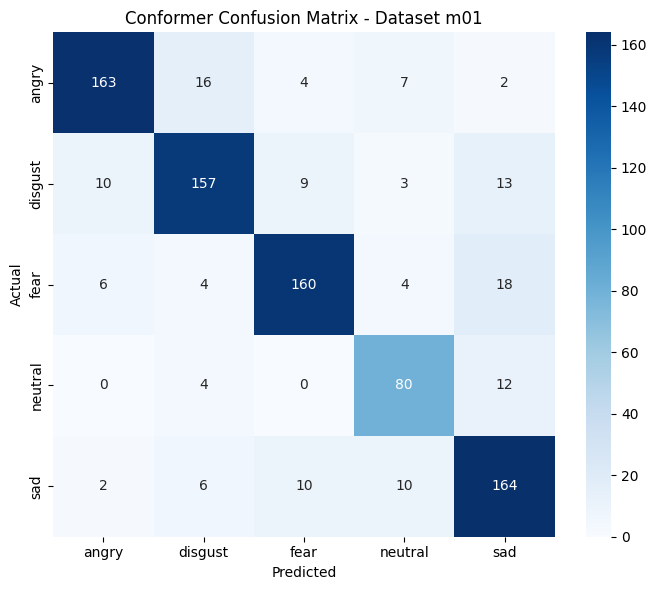

Confusion matrix plot saved at: models\confusion_matrix_conformer_m01.png


In [11]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(CM_PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix plot saved at:", CM_PLOT_PATH)


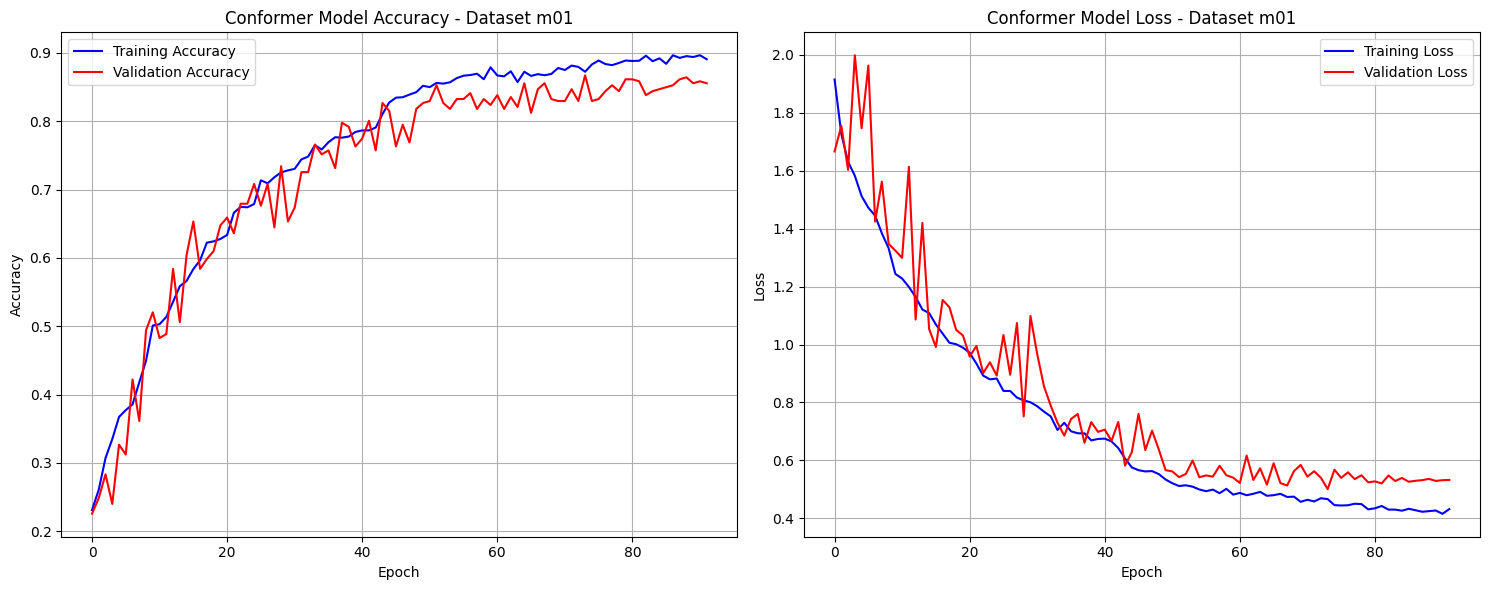

Training history plot saved at: models\training_history_conformer_m01.png


In [12]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('Conformer Model Accuracy - Dataset m01')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('Conformer Model Loss - Dataset m01')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(HISTORY_PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Training history plot saved at:", HISTORY_PLOT_PATH)


## Save preprocessing objects and final metrics

In [13]:
# Save preprocessing objects
joblib.dump(scaler, SCALER_PATH)
joblib.dump(label_encoder, LABEL_ENCODER_PATH)
joblib.dump(history.history, HISTORY_PATH)

metrics = {
    "model": "Conformer",
    "dataset": DATASET_PATH,
    "version": MODEL_VERSION,
    "split_setting": "80/20 hold-out test; validation split from training portion",
    "classes": list(label_encoder.classes_),
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
    "cohen_kappa": float(kappa),
    "epochs_trained": len(history.history["accuracy"]),
    "hyperparameters": {
        "d_model": D_MODEL,
        "num_heads": NUM_HEADS,
        "ff_dim": FF_DIM,
        "num_blocks": NUM_BLOCKS,
        "conv_kernel_size": CONV_KERNEL_SIZE,
        "dropout_rate": DROPOUT_RATE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "label_smoothing": LABEL_SMOOTHING,
        "batch_size": 32,
        "max_epochs": 100,
        "class_weight": "sqrt_balanced" if USE_CLASS_WEIGHT else "none"
    },
    "best_model_path": BEST_MODEL_PATH,
    "scaler_path": SCALER_PATH,
    "label_encoder_path": LABEL_ENCODER_PATH,
    "history_path": HISTORY_PATH,
    "confusion_matrix_plot_path": CM_PLOT_PATH,
    "training_history_plot_path": HISTORY_PLOT_PATH
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

print("Saved files:")
print("-", BEST_MODEL_PATH)
print("-", SCALER_PATH)
print("-", LABEL_ENCODER_PATH)
print("-", HISTORY_PATH)
print("-", METRICS_PATH)
print("-", CM_PLOT_PATH)
print("-", HISTORY_PLOT_PATH)

if hasattr(scaler, "mean_"):
    print("Scaler mean[0]:", round(float(scaler.mean_[0]), 2))

print("Classes:", list(label_encoder.classes_))


Saved files:
- models\best_conformer_model_m01.h5
- models\scaler_conformer_m01.pkl
- models\label_encoder_conformer_m01.pkl
- models\history_conformer_m01.pkl
- models\metrics_conformer_m01.json
- models\confusion_matrix_conformer_m01.png
- models\training_history_conformer_m01.png
Scaler mean[0]: -528.41
Classes: ['angry', 'disgust', 'fear', 'neutral', 'sad']


## Final Results Summary

In [14]:
print("\nFINAL RESULTS SUMMARY - Conformer m01")
print("=" * 60)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Epochs Trained: {len(history.history['accuracy'])}")
print(f"Dataset: {DATASET_PATH}")
print("Split: 80/20 hold-out test; validation split from training portion")
print(f"Class weight: {'sqrt_balanced' if USE_CLASS_WEIGHT else 'none'}")
print(f"Classes: {', '.join(label_encoder.classes_)}")
print(f"Best model: {BEST_MODEL_PATH}")
print(f"Scaler: {SCALER_PATH}")
print(f"Label encoder: {LABEL_ENCODER_PATH}")



FINAL RESULTS SUMMARY - Conformer m01
Test Accuracy: 0.8380
Test Loss: 0.5558
Cohen's Kappa: 0.7952
Epochs Trained: 92
Dataset: data_preprocessed/data_features_m01.csv
Split: 80/20 hold-out test; validation split from training portion
Class weight: none
Classes: angry, disgust, fear, neutral, sad
Best model: models\best_conformer_model_m01.h5
Scaler: models\scaler_conformer_m01.pkl
Label encoder: models\label_encoder_conformer_m01.pkl
